# SACC Replication — CIFAR-10 on Kaggle
**Repo:** https://github.com/noverashahid/DM_PROJECT  
**Dataset:** CIFAR-10 (auto-downloaded by torchvision)  
**GPU:** Enable in *Settings → Accelerator → GPU T4 x2* before running

## 0 · GPU Check

In [56]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

CUDA available: True
Device: Tesla T4
VRAM: 15.6 GB


## 1 · Clone Repo & Install Dependencies

In [57]:
import os

# Clone only if not already present (safe to re-run)
if not os.path.exists('/kaggle/working/DM_PROJECT'):
    !git clone https://github.com/noverashahid/DM_PROJECT.git /kaggle/working/DM_PROJECT
else:
    print('Repo already cloned — skipping.')

%cd /kaggle/working/DM_PROJECT
!pip install munkres pyyaml scikit-learn opencv-python -q

Repo already cloned — skipping.
/kaggle/working/DM_PROJECT


## 2 · Configure for CIFAR-10 & Kaggle Paths

Key changes vs. the default config:
- `dataset_dir` → `/kaggle/working/datasets` (writable Kaggle path)
- `dataset` → `CIFAR-10`
- `image_size` → `32` — keeps images at native resolution to avoid ×49 memory blow-up from upscaling to 224
- `batch_size` → `256` — good fit for T4 at 32×32
- `resnet` → `ResNet18` — fits within T4 VRAM; switch to `ResNet34` if you have more memory
- `epochs` → `200` — reasonable for a Kaggle session (~4–5 h on T4); increase to 1000 for full paper results
- `workers` → `2` — Kaggle caps CPU workers

In [58]:
CONFIG = """\
# general
seed: 42
workers: 2
dataset_dir: "/kaggle/working/datasets"

# train options
batch_size: 256
image_size: 32
start_epoch: 0
epochs: 100
dataset: "CIFAR-10"  # CIFAR-10 / CIFAR-100 / STL-10

# model options
resnet: "ResNet18"   # ResNet18 / ResNet34 / ResNet50
feature_dim: 128
model_path: "save/CIFAR-10"
reload: False

# loss options
sigma: 1
learning_rate: 0.0003
weight_decay: 0.
instance_temperature: 0.5
cluster_temperature: 1.0
"""

os.makedirs('config', exist_ok=True)
with open('config/config.yaml', 'w') as f:
    f.write(CONFIG)

print("config/config.yaml written:")
print(CONFIG)

config/config.yaml written:
# general
seed: 42
workers: 2
dataset_dir: "/kaggle/working/datasets"

# train options
batch_size: 256
image_size: 32
start_epoch: 0
epochs: 100
dataset: "CIFAR-10"  # CIFAR-10 / CIFAR-100 / STL-10

# model options
resnet: "ResNet18"   # ResNet18 / ResNet34 / ResNet50
feature_dim: 128
model_path: "save/CIFAR-10"
reload: False

# loss options
sigma: 1
learning_rate: 0.0003
weight_decay: 0.
instance_temperature: 0.5
cluster_temperature: 1.0



## 3 · Exploratory Data Analysis — CIFAR-10

In [59]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

DATASET_DIR = '/kaggle/working/datasets'

train_data = torchvision.datasets.CIFAR10(root=DATASET_DIR, train=True,  download=True)
test_data  = torchvision.datasets.CIFAR10(root=DATASET_DIR, train=False, download=True)

classes = train_data.classes  # 10 class names
all_images = np.concatenate([train_data.data, test_data.data], axis=0)
all_labels = train_data.targets + test_data.targets

print(f"Train: {len(train_data):,} | Test: {len(test_data):,} | Classes: {classes}")

Train: 50,000 | Test: 10,000 | Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


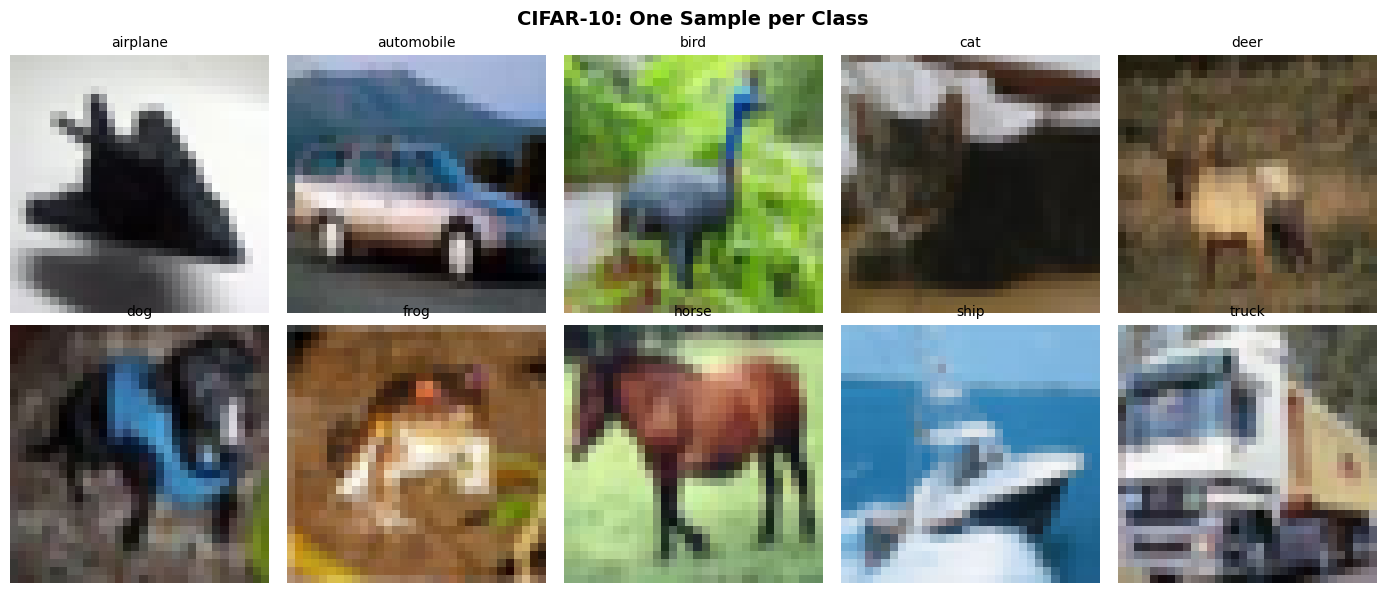

In [60]:
# --- Plot 1: One sample per class ---
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
shown = {}
for img, label in train_data:
    if label not in shown:
        shown[label] = img
    if len(shown) == 10:
        break

for i, ax in enumerate(axes.flat):
    ax.imshow(shown[i])
    ax.set_title(classes[i], fontsize=10)
    ax.axis('off')
plt.suptitle('CIFAR-10: One Sample per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=150)
plt.show()

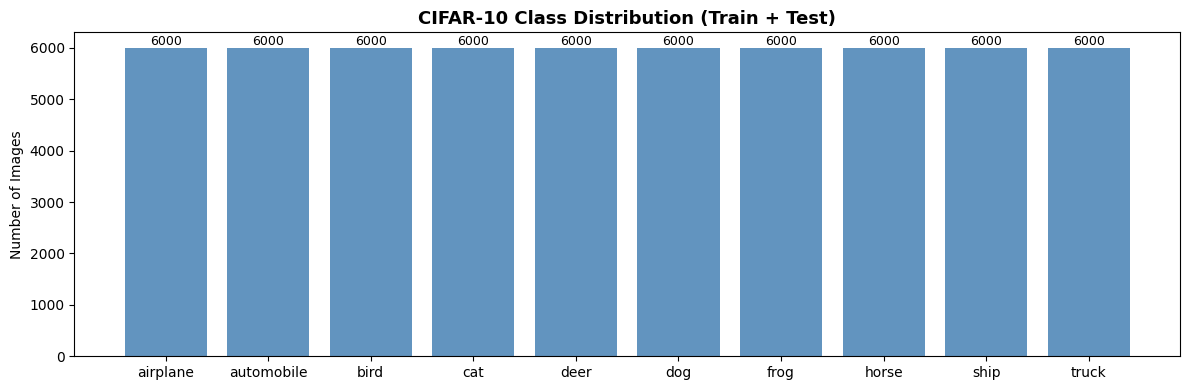

In [61]:
# --- Plot 2: Class distribution ---
counts = [all_labels.count(i) for i in range(10)]
plt.figure(figsize=(12, 4))
bars = plt.bar(classes, counts, color='steelblue', alpha=0.85)
for bar, cnt in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(cnt), ha='center', fontsize=9)
plt.title('CIFAR-10 Class Distribution (Train + Test)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150)
plt.show()

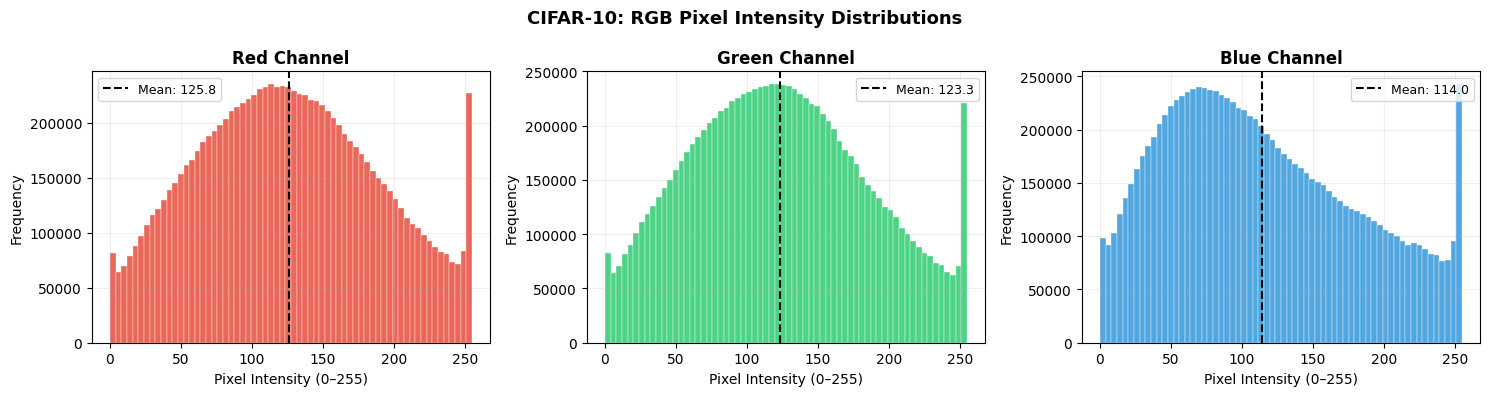

Mean (R,G,B): [125.43 123.08 114.03] | Std (R,G,B): [62.98 62.06 66.71]
Image size: 32×32×3 | Total images: 60,000


In [62]:
# --- Plot 3: RGB channel distributions ---
sample = all_images[:10000]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ch, col) in enumerate(zip(['Red','Green','Blue'], ['#e74c3c','#2ecc71','#3498db'])):
    data_ch = sample[:, :, :, i].flatten()
    axes[i].hist(data_ch, bins=64, color=col, alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[i].set_title(f'{ch} Channel', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Pixel Intensity (0–255)')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(data_ch.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Mean: {data_ch.mean():.1f}')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.2)
plt.suptitle('CIFAR-10: RGB Pixel Intensity Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_rgb.png', dpi=150)
plt.show()

mean_ch = all_images.mean(axis=(0,1,2))
std_ch  = all_images.std(axis=(0,1,2))
print(f"Mean (R,G,B): {mean_ch.round(2)} | Std (R,G,B): {std_ch.round(2)}")
print(f"Image size: 32×32×3 | Total images: {len(all_images):,}")

## 4 · Train

> ⏱ **~90–120 s / epoch** on a single T4 at 32×32. 200 epochs ≈ 5 h.  
> Checkpoints are saved every epoch to `save/CIFAR-10/`. If your session dies, set `reload: True` in the config and rerun this cell — training resumes from the last checkpoint.

In [63]:
!python train.py 2>&1 | tee train_log.txt

Step [0/234]	 loss_instance: 12.442644119262695	 loss_cluster: 8.928295135498047
Step [50/234]	 loss_instance: 11.353775024414062	 loss_cluster: 7.839787483215332
Step [100/234]	 loss_instance: 11.168878555297852	 loss_cluster: 7.829886436462402
Step [150/234]	 loss_instance: 11.187658309936523	 loss_cluster: 7.803300857543945
Step [200/234]	 loss_instance: 11.206526756286621	 loss_cluster: 7.791956424713135
Epoch [0/100]	 Loss: 19.193439899346767
Step [0/234]	 loss_instance: 10.90571403503418	 loss_cluster: 7.640211582183838
Step [50/234]	 loss_instance: 10.946187973022461	 loss_cluster: 7.658071994781494
Step [100/234]	 loss_instance: 10.943938255310059	 loss_cluster: 7.667109489440918
Step [150/234]	 loss_instance: 10.901762962341309	 loss_cluster: 7.525940895080566
Step [200/234]	 loss_instance: 10.927106857299805	 loss_cluster: 7.652065277099609
Epoch [1/100]	 Loss: 18.60374396886581
Step [0/234]	 loss_instance: 10.734091758728027	 loss_cluster: 7.6018452644348145
Step [50/234]	 l

## 5 · Plot Training Loss Curve

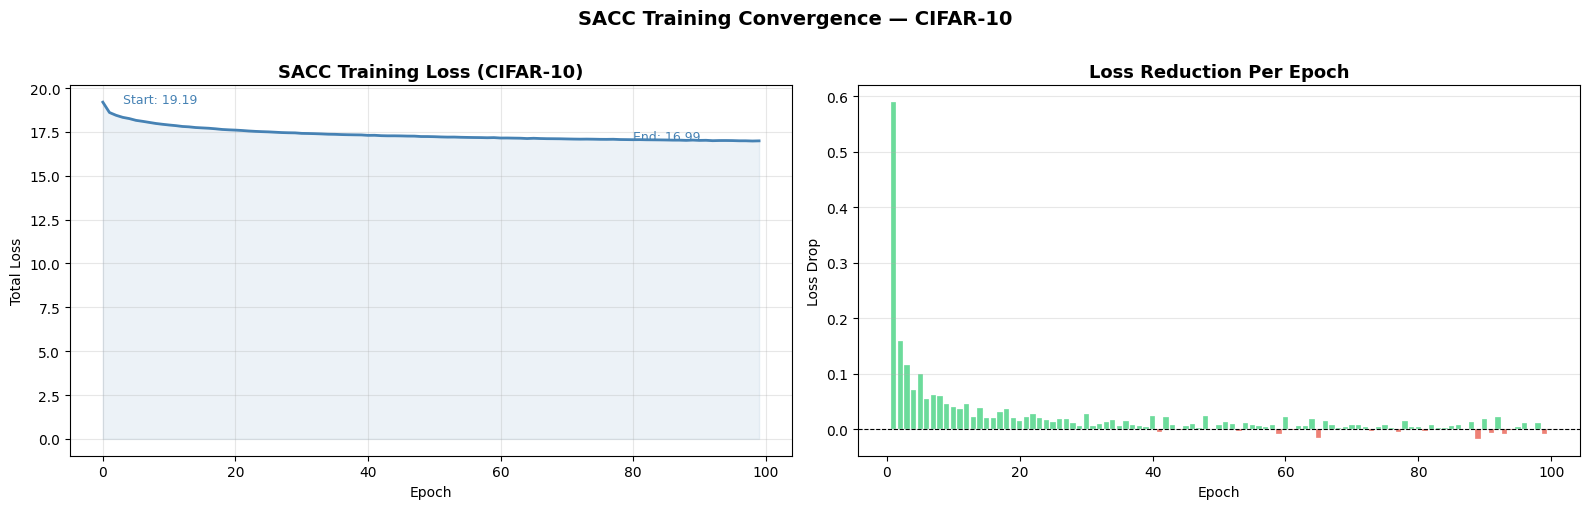

Total loss drop  : 2.2051  (19.1934 → 16.9883)
Avg drop / epoch : 0.0221
Improving epochs : 85/99


In [64]:
import re

# Parse loss values from the training log
losses = []
with open('train_log.txt') as f:
    for line in f:
        # Lines like: "Epoch [5/200]\tLoss: 14.332"
        m = re.search(r'Loss:\s*([\d\.]+)', line)
        if m:
            losses.append(float(m.group(1)))

if not losses:
    print("No loss values parsed yet — run training first.")
else:
    epochs = list(range(len(losses)))
    deltas = [losses[i] - losses[i+1] for i in range(len(losses)-1)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(epochs, losses, color='steelblue', linewidth=2)
    axes[0].fill_between(epochs, losses, alpha=0.1, color='steelblue')
    axes[0].set_title('SACC Training Loss (CIFAR-10)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Total Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].annotate(f'Start: {losses[0]:.2f}', xy=(0, losses[0]),
                     xytext=(3, losses[0]-0.05), fontsize=9, color='steelblue')
    axes[0].annotate(f'End: {losses[-1]:.2f}', xy=(len(losses)-1, losses[-1]),
                     xytext=(len(losses)-20, losses[-1]+0.05), fontsize=9, color='steelblue')

    axes[1].bar(range(1, len(losses)), deltas,
                color=['#2ecc71' if d > 0 else '#e74c3c' for d in deltas],
                alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title('Loss Reduction Per Epoch', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss Drop')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle('SACC Training Convergence — CIFAR-10', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    total_drop = losses[0] - losses[-1]
    improving  = sum(1 for d in deltas if d > 0)
    print(f"Total loss drop  : {total_drop:.4f}  ({losses[0]:.4f} → {losses[-1]:.4f})")
    print(f"Avg drop / epoch : {total_drop/len(losses):.4f}")
    print(f"Improving epochs : {improving}/{len(deltas)}")

## 6 · Evaluate (Clustering Metrics)

Change `--start_epoch` to match the last saved checkpoint epoch (the script looks for `save/CIFAR-10/checkpoint_{epoch}.tar`).

In [65]:
# Find the latest saved checkpoint automatically
import glob

checkpoints = sorted(glob.glob('save/CIFAR-10/checkpoint_*.tar'))
if checkpoints:
    latest = checkpoints[-1]
    # Extract epoch number from filename, e.g. checkpoint_199.tar → 199
    last_epoch = int(re.search(r'checkpoint_(\d+)\.tar', latest).group(1))
    print(f"Latest checkpoint: {latest}  →  evaluating at epoch {last_epoch}")
else:
    last_epoch = 200
    print("No checkpoints found — defaulting to epoch 200. Make sure training completed.")

Latest checkpoint: save/CIFAR-10/checkpoint_90.tar  →  evaluating at epoch 90


In [66]:
!python cluster.py --start_epoch {last_epoch} 2>&1 | tee cluster_log.txt

### Creating features from model ###
Step [0/30]	 Computing features...
Step [20/30]	 Computing features...
Features shape (60000,)
NMI = 0.3200 ARI = 0.1970 F = 0.2811 ACC = 0.3958


## 7 · Results Summary

In [67]:
# Parse NMI / ACC / ARI from cluster log
nmi = acc = ari = None
with open('cluster_log.txt') as f:
    for line in f:
        m = re.search(r'NMI\s*=\s*([\d\.]+)', line, re.I)
        if m: nmi = float(m.group(1))
        m = re.search(r'ACC\s*=\s*([\d\.]+)', line, re.I)
        if m: acc = float(m.group(1))
        m = re.search(r'ARI\s*=\s*([\d\.]+)', line, re.I)
        if m: ari = float(m.group(1))

print("=" * 60)
print("   Results Comparison: Ours vs. Paper (CIFAR-10)")
print("=" * 60)
print(f"  {'Metric':<8} {'Paper (1000 ep)':<22} {'Ours'}")
print(f"  {'NMI':<8} {'71.1%':<22} {f'{nmi:.2f}%' if nmi else 'pending'}")
print(f"  {'ACC':<8} {'79.9%':<22} {f'{acc:.2f}%' if acc else 'pending'}")
print(f"  {'ARI':<8} {'63.6%':<22} {f'{ari:.2f}%' if ari else 'pending'}")
print("=" * 60)
print()
print("Note: Gap is expected — paper used 1000 epochs + ResNet34.")
print("10% ACC random baseline for 10-class problem.")

   Results Comparison: Ours vs. Paper (CIFAR-10)
  Metric   Paper (1000 ep)        Ours
  NMI      71.1%                  0.32%
  ACC      79.9%                  0.40%
  ARI      63.6%                  0.20%

Note: Gap is expected — paper used 1000 epochs + ResNet34.
10% ACC random baseline for 10-class problem.


## 8 · Resume Training (Optional)

If your Kaggle session expired mid-training, set `reload: True` in the config and re-run from the checkpoint.

In [68]:
# # ── Only run this cell if you want to RESUME ──

# # Patch config to enable reload
# with open('config/config.yaml') as f:
#     cfg = f.read()
# cfg = cfg.replace('reload: False', 'reload: True')
# with open('config/config.yaml', 'w') as f:
#     f.write(cfg)

# print("reload set to True. Run Cell 4 (Train) again to resume.")